# Explore here

## Step 1: Problem statement and data collection

Problem statement: Given a dataset from the National Institute of Diabetes and Digestive and Kidney Diseases, set up a decision tree to predict whether or not a patient has diabetes.

In [22]:
# Import dataset to start working with it
import pandas as pd

raw_data = pd.read_csv("../data/raw/diabetes.csv", sep=",")

## Step 2: Exploration and data cleaning

In [23]:
print(f"Raw data shape: {raw_data.shape}")
print(raw_data.info())

Raw data shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Unlike prior exercise, doesn't look as though any of our columns have missing data at all, which simplifies matters.

~~Will do a simple drop_duplicates.~~ Skipped dropping duplicates because in a large enough population we could have two real people with similar/same stats. I don't see anything like an ID column to need to get fancier with.

In [24]:
# raw_data.drop_duplicates(inplace=True)


print(raw_data.shape)
raw_data.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# remove data considered irrelevant...

# skipping the below because as of yet, none of the columns in the raw dataset look strictly-irrelevant to me

# raw_data.drop(
#    ["id", "name", "host_name", "last_review", "reviews_per_month"],
#    axis=1,
#    inplace=True,
# )


# raw_data.head()

## Step 3: Analysis of univariate variables
### categorical variables
Categorical, non-numeric variables in this dataframe include: outcome. That's it.  The rest are numeric.

All of these are plausible to me as relevant.

In [26]:
categorical_variables = [
    "Outcome",
]

for each_categorical_variable in categorical_variables:
    print(f"\n\t{each_categorical_variable}s:")
    for each_possible_value in sorted(
        raw_data[f"{each_categorical_variable}"].unique()
    ):
        print(each_possible_value)


	Outcomes:
0
1


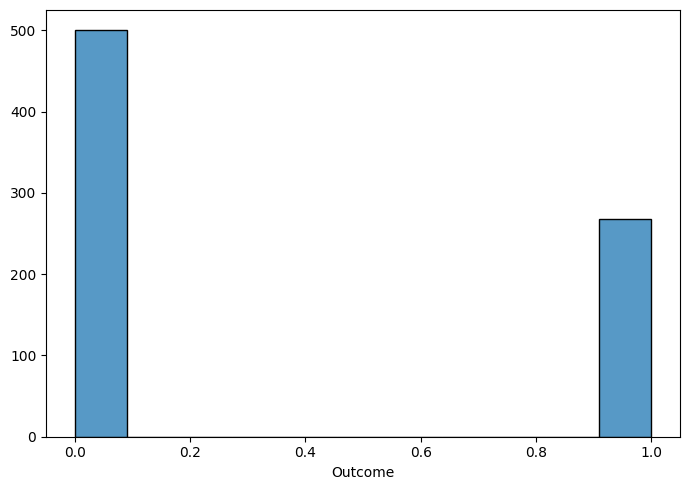

In [27]:
# histogram-plot each categorical variable

import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(1, 1, figsize=(7, 5))

# Create a multiple histogram
sns.histplot(data=raw_data, x="Outcome").set(ylabel=None)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

- Many more diabetics in the dataset than I would've guessed.

### numeric variables

Numerical, non-categorical variables in the dataset include: everything but Outcome

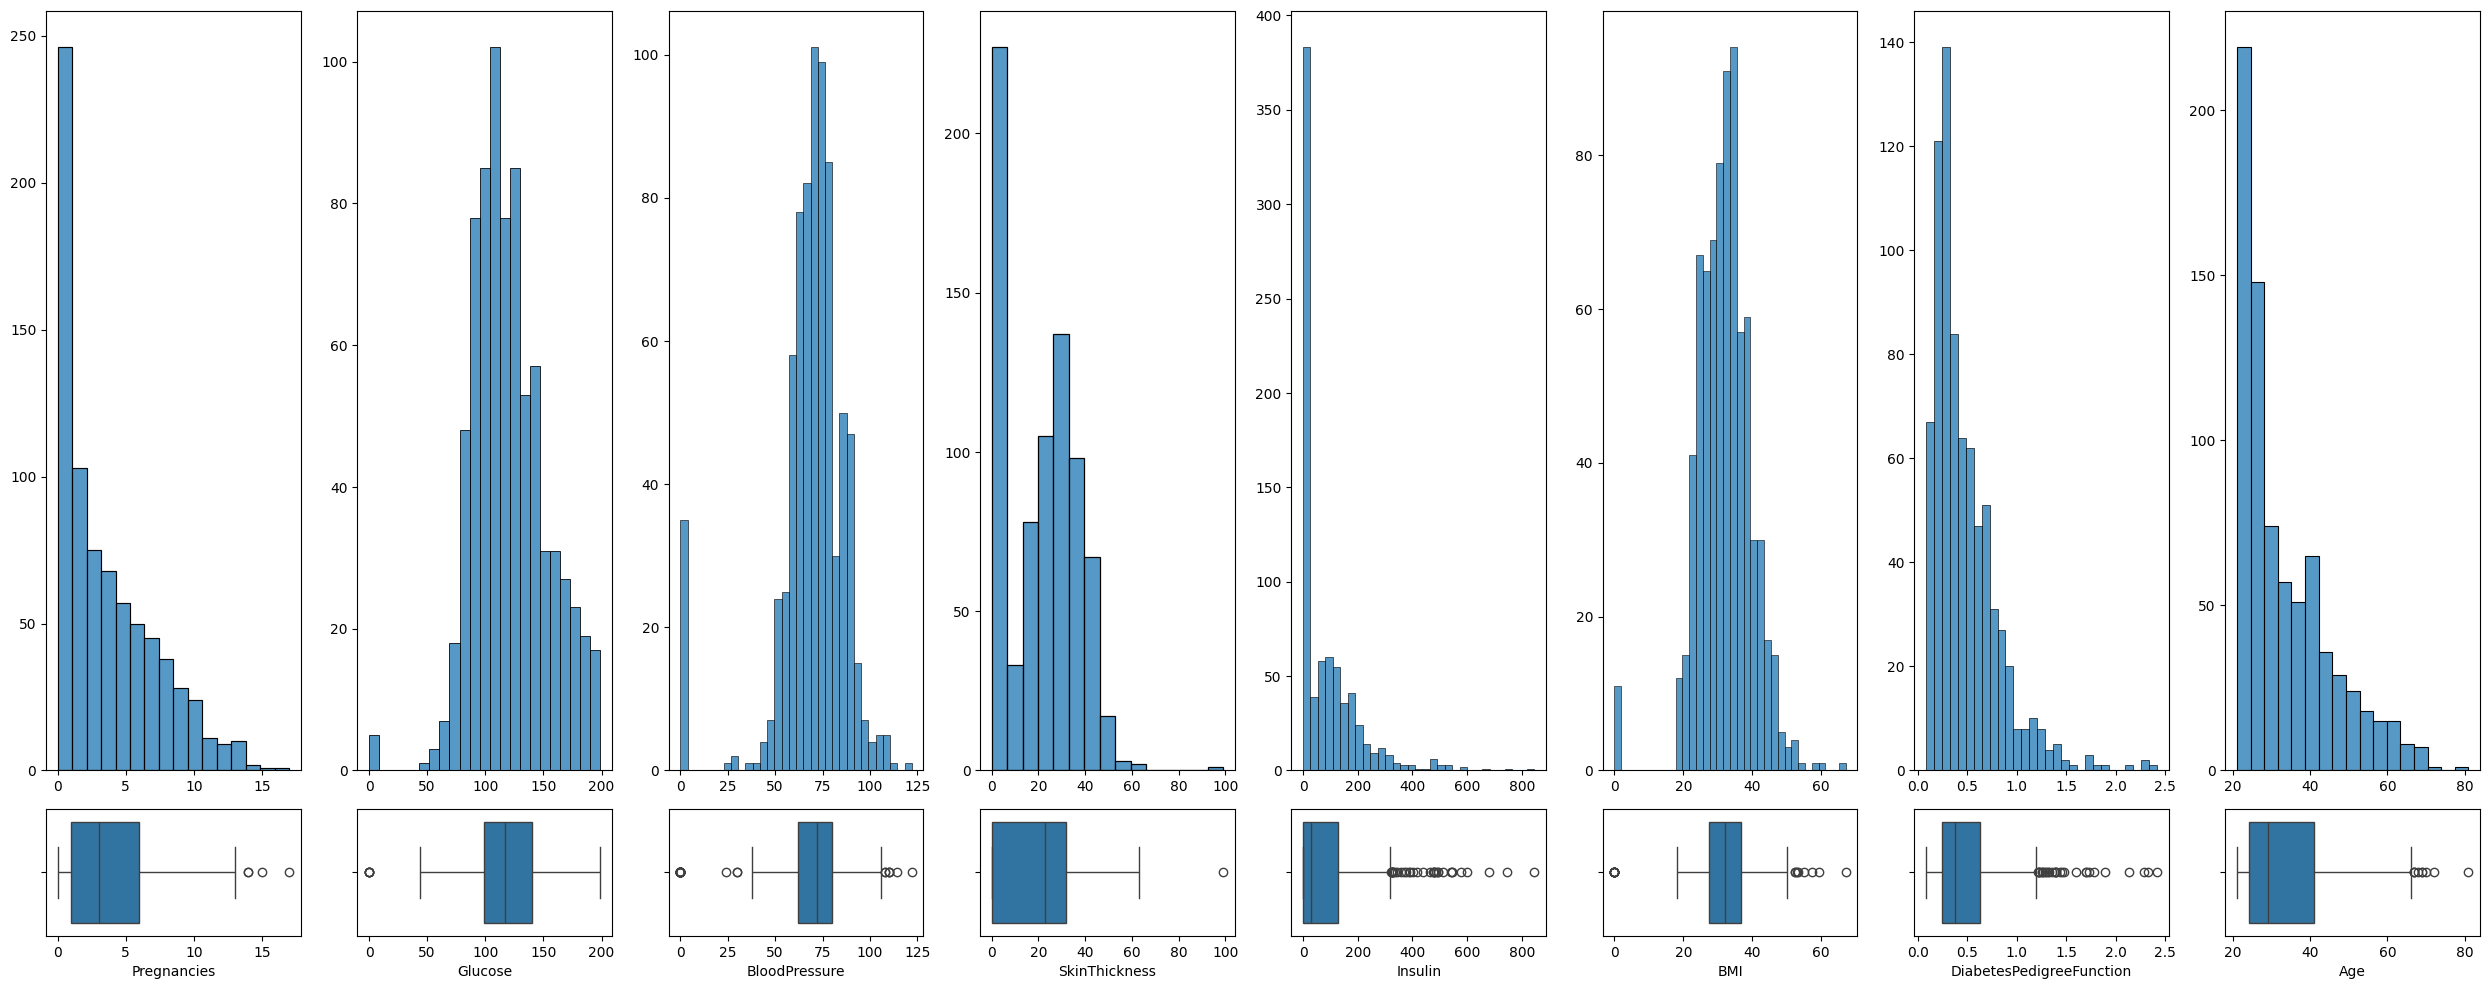

In [28]:
numeric_variables = raw_data.columns[~raw_data.columns.isin(categorical_variables)]

fig, axis = plt.subplots(
    2, len(numeric_variables), figsize=(25, 10), gridspec_kw={"height_ratios": [6, 1]}
)

# Creating a multiple figure with histograms and box plots
temp_column_index = 0
for each_numeric_variable in numeric_variables:
    sns.histplot(
        ax=axis[0, temp_column_index], data=raw_data, x=f"{each_numeric_variable}"
    ).set(xlabel=None, ylabel=None)
    sns.boxplot(
        ax=axis[1, temp_column_index], data=raw_data, x=f"{each_numeric_variable}"
    )
    temp_column_index += 1

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

From this it looks like:
- some women had upwards of a dozen pregnancies (!)
- Someone's runnning around out there with either no glucose in their system or got an invalid measurement of it
- Guessing the outliers like 0 BMI correspond to unknowns or mis-entered data (a different cell cleans those up)

## Step 4: Analysis of multivariate variables
### Numerical-numerical analysis
Am curious to see whether/how there are correlations between pregnancies and skin thickness vs. more intuitive correlations such as age.

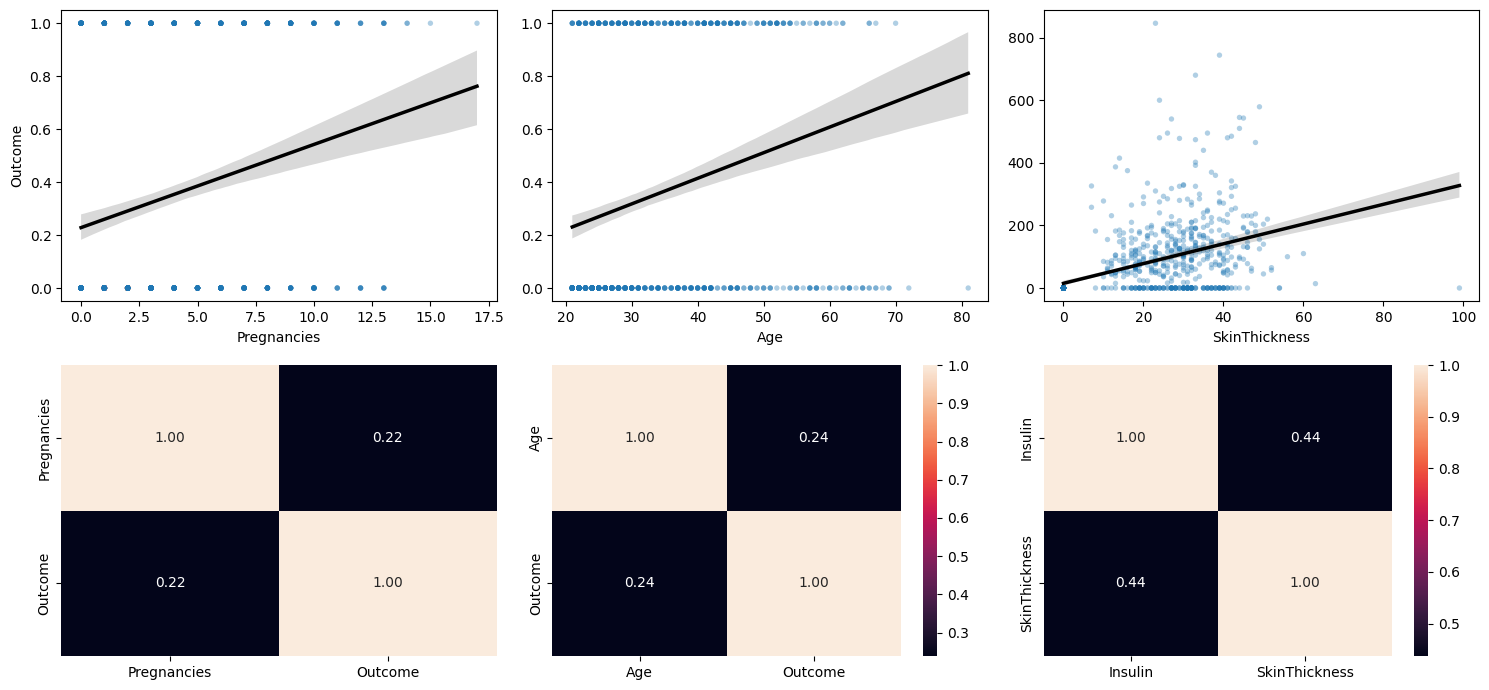

In [29]:
fig, axis = plt.subplots(2, 3, figsize=(15, 7))

# Create a multiple scatter diagram
common_scatter = {"s": 15, "alpha": 0.35, "edgecolor": "none"}
common_line = {"color": "black", "lw": 2.5, "zorder": 5}

sns.regplot(
    ax=axis[0, 0],
    data=raw_data,
    x="Pregnancies",
    y="Outcome",
    scatter_kws=common_scatter,
    line_kws=common_line,
)
sns.heatmap(
    raw_data[["Pregnancies", "Outcome"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 0],
    cbar=False,
)

sns.regplot(
    ax=axis[0, 1],
    data=raw_data,
    x="Age",
    y="Outcome",
    scatter_kws=common_scatter,
    line_kws=common_line,
).set(ylabel=None)
sns.heatmap(
    raw_data[["Age", "Outcome"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 1],
)

sns.regplot(
    ax=axis[0, 2],
    data=raw_data,
    x="SkinThickness",
    y="Insulin",
    scatter_kws=common_scatter,
    line_kws=common_line,
).set(ylabel=None)
sns.heatmap(
    raw_data[["Insulin", "SkinThickness"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 2],
)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

Increasing # of pregnancies and aging, both appear correlated to diabetes.  I was not aware of the correlation between increasing insulin and incrasting skin thickness, but that appears to be indicated by this chart.

### categorical-categorical analysis

##### skipped because there's only one categorical feature to cover

In [30]:
# skipped because there's only one categorical feature to cover

#### Correlation analysis


##### skipped; covered by heatmap in a cell not much further below

### numerical-categorical analysis

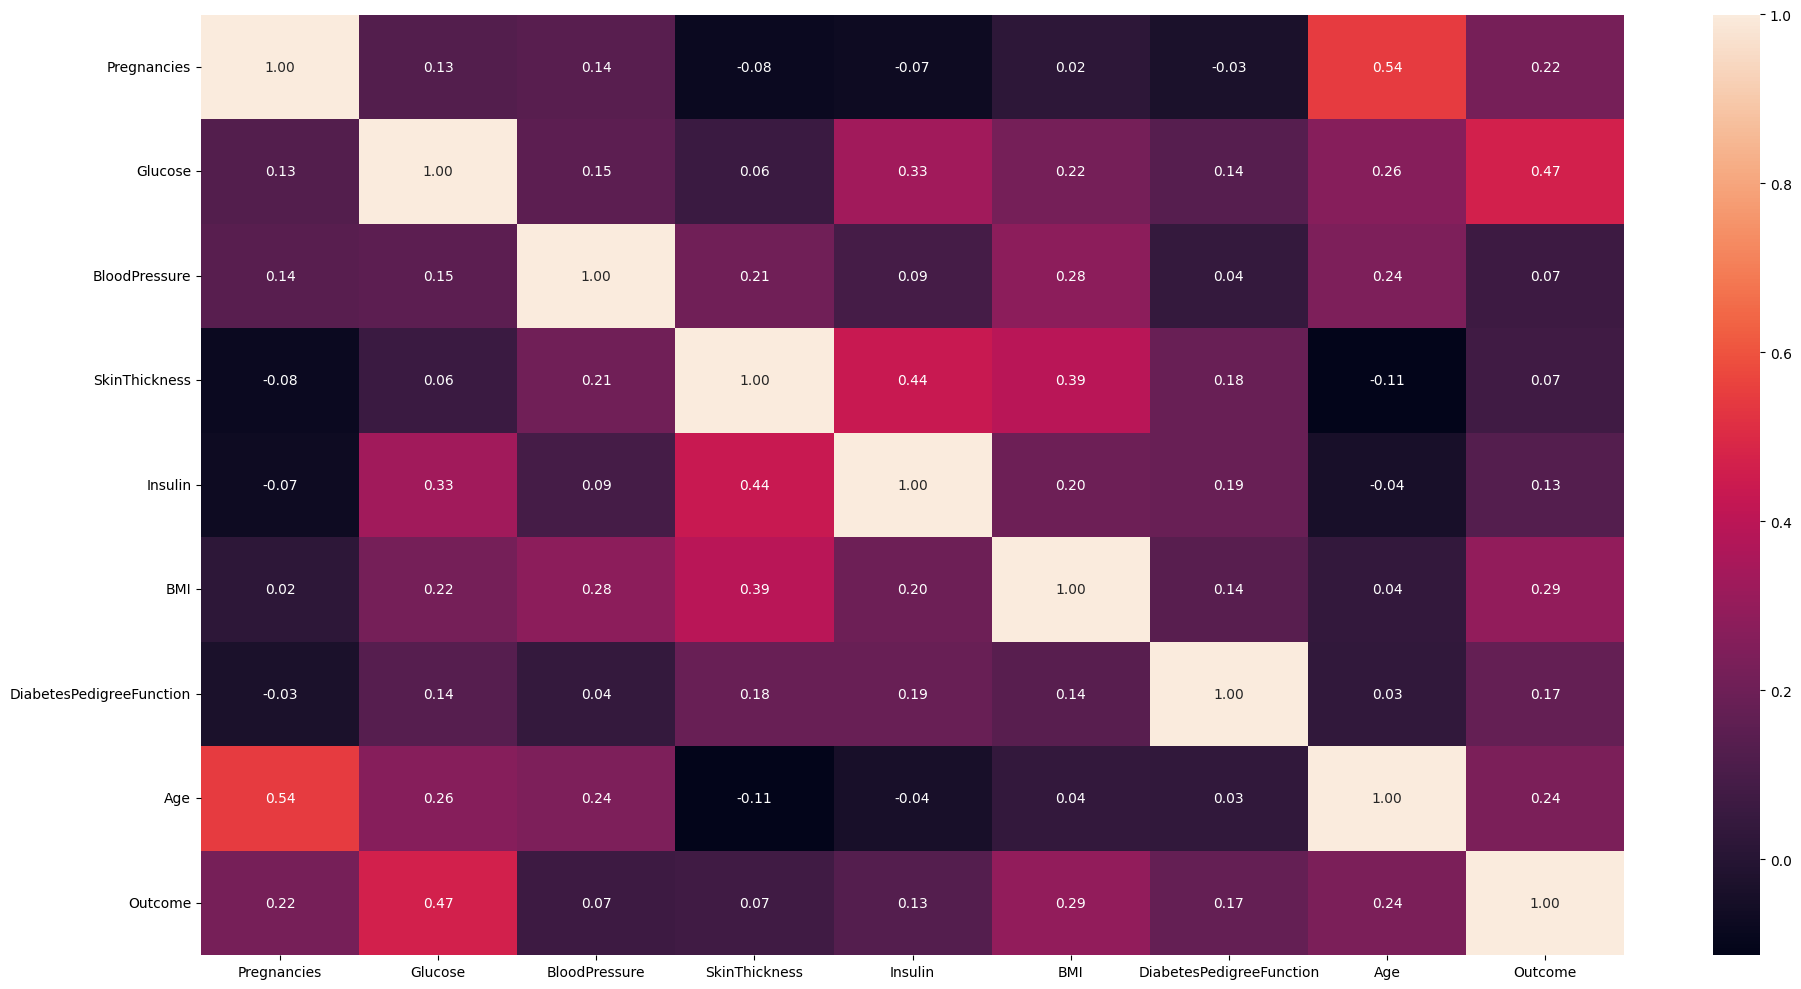

In [31]:
fig, axis = plt.subplots(figsize=(20, 10))

sns.heatmap(
    raw_data[list(raw_data.columns)].corr(),
    annot=True,
    fmt=".2f",
)

plt.tight_layout()

plt.show()

Based on the above, I'd assess the strongest correlations are between age and pregnancies, between glucose and outcome, and between insulin and skin thickness.

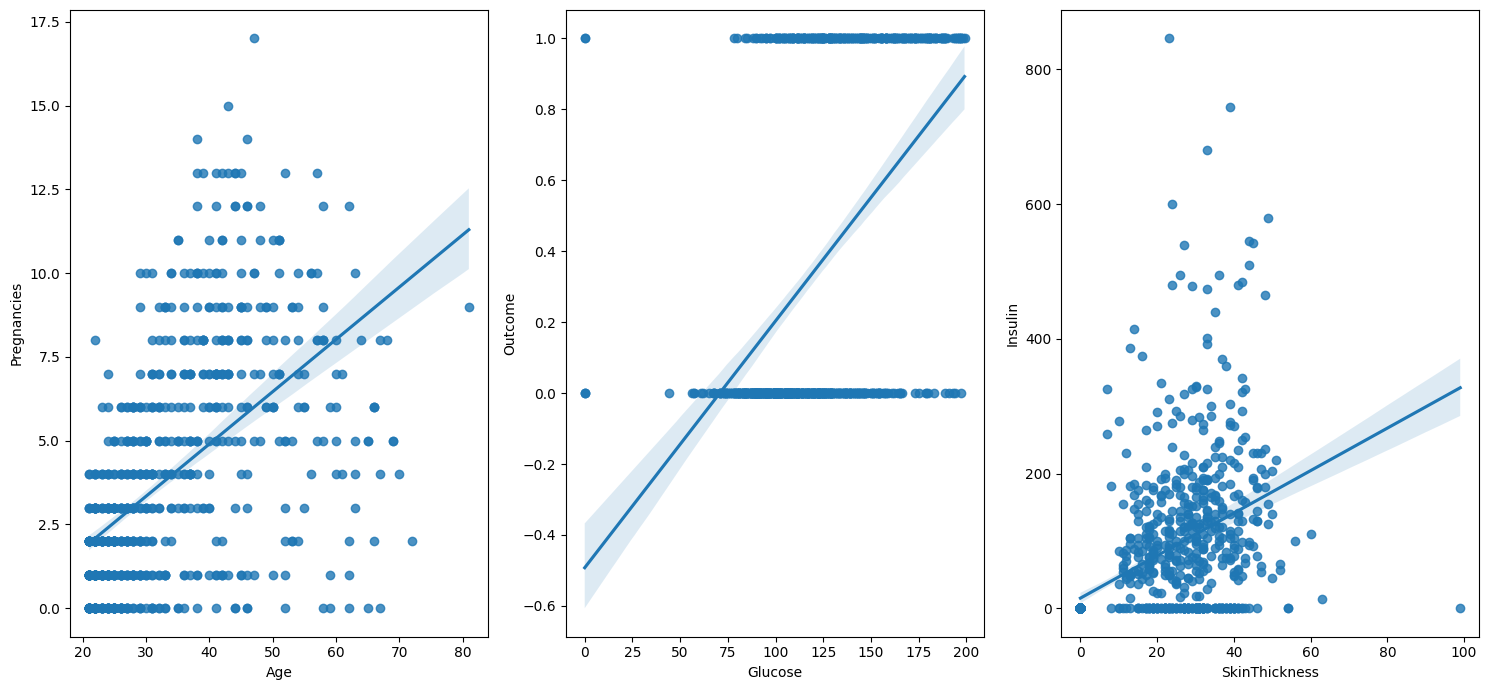

In [32]:
fig, axis = plt.subplots(figsize=(15, 7), ncols=3)

sns.regplot(ax=axis[0], data=raw_data, x="Age", y="Pregnancies")
sns.regplot(ax=axis[1], data=raw_data, x="Glucose", y="Outcome")
sns.regplot(ax=axis[2], data=raw_data, x="SkinThickness", y="Insulin")

plt.tight_layout()

plt.show()

Based on these regression plots:
- More likely to have had more pregnancies if you're an older person
- More likely to be diagnosed with diabetes if you have higher glucose levels
- More likely to have thicker skin if you have high insulin, or vice versa


In [ ]:
# sns.pairplot(data=raw_data)

In [34]:
raw_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


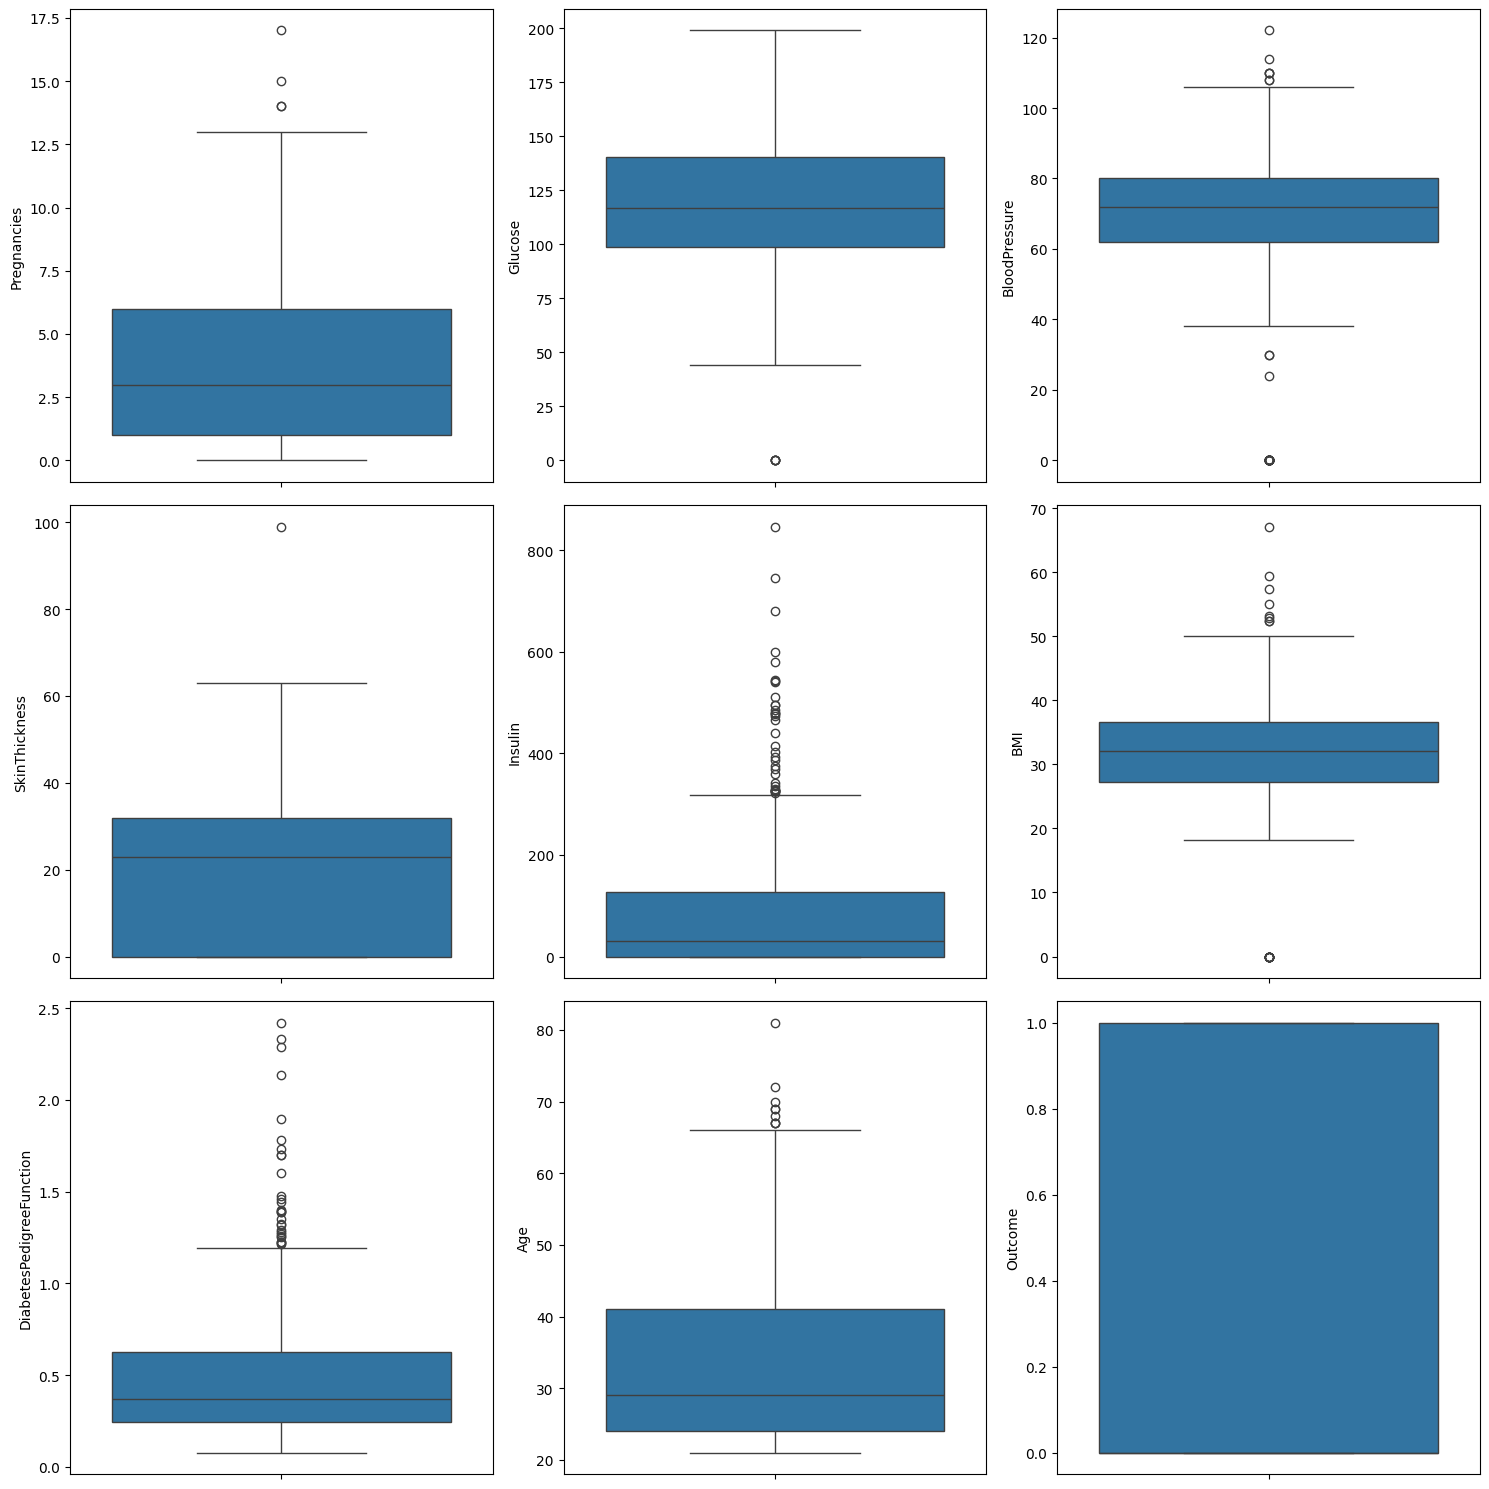

In [35]:
fig, axis = plt.subplots(3, 3, figsize=(15, 15))

sns.boxplot(ax=axis[0, 0], data=raw_data, y="Pregnancies")
sns.boxplot(ax=axis[0, 1], data=raw_data, y="Glucose")
sns.boxplot(ax=axis[0, 2], data=raw_data, y="BloodPressure")
sns.boxplot(ax=axis[1, 0], data=raw_data, y="SkinThickness")
sns.boxplot(ax=axis[1, 1], data=raw_data, y="Insulin")
sns.boxplot(ax=axis[1, 2], data=raw_data, y="BMI")
sns.boxplot(ax=axis[2, 0], data=raw_data, y="DiabetesPedigreeFunction")
sns.boxplot(ax=axis[2, 1], data=raw_data, y="Age")
sns.boxplot(ax=axis[2, 2], data=raw_data, y="Outcome")

plt.tight_layout()

plt.show()

Outcome variable appears not to have any outliers in need of finding and eliminating.  But this is a case where we do have non-y-target outliers to clean up, because physiologically impossible to live with certain characteristics == 0.

In [36]:
zeros_of_these_are_invalid = ["Glucose", "BloodPressure", "BMI"]
raw_data = raw_data[raw_data[zeros_of_these_are_invalid].ne(0).all(axis=1)]
raw_data.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000
mean,3.866022,121.882597,72.400552,21.443370,84.494475,32.467127,0.474765,33.350829,0.343923
std,3.362803,30.750030,12.379870,15.732756,117.016513,6.888941,0.332315,11.765393,0.475344
min,0.000000,44.000000,24.000000,0.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,0.000000,0.000000,27.500000,0.245000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,24.000000,48.000000,32.400000,0.379000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,130.500000,36.600000,0.627500,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Can confirm this worked by seeing minimum blood pressure etc. is no longer zero.

### Building decision tree model

##### Splitting training vs test data

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split

num_variables = numeric_variables


X = raw_data.drop("Outcome", axis=1)
y = raw_data["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [38]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [39]:
y_pred = model.predict(X_test)
y_pred
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7862068965517242

In [40]:
model.save_model("xgb_classifier_default_42.json")

### Getting more selective with data

### Scaling
No need to scale for decision trees

In [ ]:
# normalization scaler
# from sklearn.preprocessing import StandardScaler
#
# scaler = StandardScaler()
# scaler.fit(X_train)
#
# X_train_norm = scaler.transform(X_train)
# X_train_norm = pd.DataFrame(X_train_norm, index=X_train.index, columns=num_variables)
#
# X_test_norm = scaler.transform(X_test)
# X_test_norm = pd.DataFrame(X_test_norm, index=X_test.index, columns=num_variables)
#
# X_train_norm.head()

In [ ]:
## min-max scaler
# from sklearn.preprocessing import MinMaxScaler
#
# scaler = MinMaxScaler()
# scaler.fit(X_train)
#
# X_train_scal = scaler.transform(X_train)
# X_train_scal = pd.DataFrame(X_train_scal, index=X_train.index, columns=num_variables)
#
# X_test_scal = scaler.transform(X_test)
# X_test_scal = pd.DataFrame(X_test_scal, index=X_test.index, columns=num_variables)
#
# X_train_scal.head()

### feature selection for selecting most-relevant features to use for building ML model


In [ ]:
# feature selection for selecting most-relevant features to use for building ML model

from sklearn.feature_selection import f_classif, SelectKBest

# With a value of k = 5 we implicitly mean that we want to remove 3 features from the 8-column dataset
selection_model = SelectKBest(f_classif, k=5)
# selection_model.fit(X_train_scal, y_train)
selection_model.fit(X_train, y_train)
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(
    selection_model.transform(X_train), columns=X_train.columns.values[ix]
)
X_test_sel = pd.DataFrame(
    selection_model.transform(X_test), columns=X_test.columns.values[ix]
)

X_train_sel.head()

,Pregnancies,Glucose,BMI,DiabetesPedigreeFunction,Age
0,0.0,137.0,27.3,0.231,59.0
1,3.0,78.0,31.0,0.248,26.0
2,1.0,82.0,21.2,0.415,23.0
3,13.0,104.0,31.2,0.465,38.0
4,1.0,97.0,18.2,0.147,21.0


In [44]:
X_train_sel["Outcome"] = list(y_train)
X_test_sel["Outcome"] = list(y_test)

In [45]:
X_train_sel.to_csv(
    "../data/interim/clean_decision_tree_diabetes_train.csv",
    index=False,
)
X_test_sel.to_csv("../data/interim/clean_decision_tree_diabetes_test.csv", index=False)

In [46]:
import pandas as pd

train_data = pd.read_csv("../data/interim/clean_decision_tree_diabetes_train.csv")
test_data = pd.read_csv("../data/interim/clean_decision_tree_diabetes_test.csv")


train_data.head()

,Pregnancies,Glucose,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.0,137.0,27.3,0.231,59.0,0
1,3.0,78.0,31.0,0.248,26.0,1
2,1.0,82.0,21.2,0.415,23.0,0
3,13.0,104.0,31.2,0.465,38.0,1
4,1.0,97.0,18.2,0.147,21.0,0


In [47]:
X_train = train_data.drop(["Outcome"], axis=1)
y_train = train_data["Outcome"]
X_test = test_data.drop(["Outcome"], axis=1)
y_test = test_data["Outcome"]

In [ ]:
model_using_kbest = XGBClassifier(random_state=42)
model_using_kbest.fit(X_train, y_train)
y_pred = model_using_kbest.predict(X_test)
y_pred

array([0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0])

#### Accuracy score without hyperparameter optimization

In [210]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7655172413793103

## Tuning

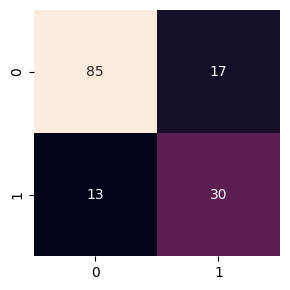

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

untuned_confusion_matrix = confusion_matrix(y_test, y_pred)

# Let's draw this matrix to make it more visual
cm_df = pd.DataFrame(untuned_confusion_matrix)

plt.figure(figsize=(3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.show()

#### Hyperparameter optimizing
##### Grid search

In [ ]:
from sklearn.model_selection import GridSearchCV

# We define the parameters that we want to adjust by hand
hyperparams = {
    "n_estimators": [100, 150],
    "learning_rate": [2, 5],
    "loss": [0.5, 1, 2],
    "subsample": [0.8, 1],
    # only the four above relate to boosting, the rest below are about decision trees
    "max_depth": [3, 5, 8],
    # "min_samples_split":[],
    # "min_child_weight":[],
    # "min_samples_leaf":[],
    # "max_features":[]
}


# We initialize the grid
grid = GridSearchCV(
    model,
    hyperparams,
    scoring="accuracy",
    cv=5,
)
grid

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [2, 5], 'loss': [0.5, 1, 2],
                         'max_depth': [3, 5, 8], 'n_estimators': [100, 150],
                         'subsample': [0.8, 1]},
             scoring='accuracy')

In [72]:
def warn(*args, **kwargs):
    pass


import warnings

warnings.warn = warn

grid.fit(X_train, y_train)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'learning_rate': 2, 'loss': 0.5, 'max_depth': 8, 'n_estimators': 150, 'subsample': 1}


In [75]:
model_grid = XGBClassifier(
    learning_rate=2,
    loss=0.5,
    n_estimators=150,
    subsample=1,
    max_depth=8,
    random_state=42,
)
model_grid.fit(X_train, y_train)
y_pred = model_grid.predict(X_test)

grid_accuracy = accuracy_score(y_test, y_pred)
grid_accuracy

0.7448275862068966

##### Random search hyperparameter optimization-hunting

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

# We define the parameters that we want to adjust by hand
hyperparams = {
    "n_estimators": [100, 150],
    "learning_rate": [2, 5],
    "loss": [0.5, 1, 2],
    "subsample": [0.8, 1],
    # only the four above relate to boosting, the rest below are about decision trees
    "max_depth": [3, 5, 8, 13],
    "min_samples_split": [3, 5, 8],
    "min_child_weight": [1, 3, 5, 8],
    "min_samples_leaf": [1, 3, 5, 8],
    "max_features": [1, 3, 5, 8],
}


# We initialize the random search
random_search = RandomizedSearchCV(
    model,
    hyperparams,
    scoring="accuracy",
    cv=5,
)
random_search

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [2, 5],
                                        'loss': [0.5, 1, 2],
                                        'max_depth': [3, 5, 8],
                                        'max_features': [1, 3, 5, 8],
                                        'min_child_weight': [1, 3, 5, 8],
                                        'min_samples_leaf': [1, 3, 5, 8],
                                        'min_samples_split': [3, 5, 8],
                                        'n_estimators': [100, 150],
                                        'subsample': [0.8, 1]},
                   scoring='accuracy')

In [77]:
random_search.fit(X_train, y_train)

print(f"Best hyperparameters: {random_search.best_params_}")

Best hyperparameters: {'subsample': 0.8, 'n_estimators': 150, 'min_samples_split': 3, 'min_samples_leaf': 3, 'min_child_weight': 1, 'max_features': 5, 'max_depth': 8, 'loss': 1, 'learning_rate': 2}


In [78]:
model_random_search = XGBClassifier(
    learning_rate=2,
    loss=1,
    n_estimators=150,
    subsample=0.8,
    min_samples_split=3,
    min_samples_leaf=3,
    min_child_weight=1,
    max_features=5,
    max_depth=8,
    random_state=42,
)
model_random_search.fit(X_train, y_train)
y_pred = model_random_search.predict(X_test)

random_search_accuracy = accuracy_score(y_test, y_pred)
random_search_accuracy

0.7379310344827587

### Trying out bayesian search tuning

In [80]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

# We define the parameters that we want to adjust by hand
search_space = {
    "n_estimators": [100, 150],
    "learning_rate": [2, 5],
    "loss": [0.5, 1, 2],
    "subsample": [0.8, 1],
    # only the four above relate to boosting, the rest below are about decision trees
    "max_depth": [3, 5, 8, 13],
    "min_samples_split": [3, 5, 8],
    "min_child_weight": [1, 3, 5, 8],
    "min_samples_leaf": [1, 3, 5, 8],
    "max_features": [1, 3, 5, 8],
}


bayes_cv = BayesSearchCV(
    XGBClassifier(random_state=42, bootstrap=True),
    search_space,
    n_iter=50,  # iterations (= Bayesian steps)
    cv=5,
    scoring="accuracy",
    n_jobs=-1,  # parallel cores
    random_state=42,
)

bayes_cv.fit(X_train, y_train)
print("Best params:", bayes_cv.best_params_)


Best params: OrderedDict({'learning_rate': 2, 'loss': 0.5, 'max_depth': 8, 'max_features': 5, 'min_child_weight': 1, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 111, 'subsample': 1.0})


In [81]:
forest_bayesian_search = XGBClassifier(
    learning_rate=2,
    loss=0.5,
    n_estimators=111,
    subsample=1.0,
    min_samples_split=5,
    min_samples_leaf=3,
    min_child_weight=1,
    max_features=5,
    max_depth=8,
    random_state=42,
)
forest_bayesian_search.fit(X_train, y_train)
y_pred = forest_bayesian_search.predict(X_test)

bayesian_search_accuracy = accuracy_score(y_test, y_pred)
bayesian_search_accuracy


0.7448275862068966